# Reservoir-to-Market Optimisation with NeqSim Process Equipment

This notebook builds a **complete reservoir-to-market chain entirely from NeqSim
process equipment** and solves it with `ProcessSystem` and `ProcessModel`. No
reservoir, well or pipeline physics is implemented in Python — every pressure,
rate and power comes from NeqSim unit operations:

| Stage | NeqSim equipment |
|-------|------------------|
| Reservoir (material-balance tank, depletion) | `SimpleReservoir` |
| Well inflow (IPR / deliverability) | `WellFlow` |
| Tubing (vertical lift) and flowline | `PipeBeggsAndBrills` |
| Gathering manifold | `Mixer` |
| Topsides inlet separation | `Separator` |
| Export compression | `Compressor` + `Cooler` |
| Subsurface / topsides composition | `ProcessModel` (two `ProcessSystem` areas) |

The workflow mirrors an integrated production model (MBAL + PROSPER + GAP /
Pipesim): the reservoir sets the pressure, the wells and flowlines convert that
into a deliverable arrival rate, and the topsides train compresses gas to the
export grid. We then **deplete the reservoir over field life** and **optimise the
production rate against an export-compression constraint** — all by re-running
the NeqSim flowsheet.


## 1. Environment setup

Load NeqSim from the workspace build (`target/classes`) via the devtools helper
so the latest Java classes are available.


In [1]:
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (
            candidate / "devtools" / "neqsim_dev_setup.py"
        ).exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)

import numpy as np
import matplotlib.pyplot as plt

print("NeqSim ready — reservoir-to-market chain will be built from process equipment.")


NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.13.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim ready — reservoir-to-market chain will be built from process equipment.


In [2]:
# NeqSim process-equipment classes used to build the reservoir-to-market chain
SystemPrEos = ns.JClass("neqsim.thermo.system.SystemPrEos")

SimpleReservoir = ns.JClass("neqsim.process.equipment.reservoir.SimpleReservoir")
WellFlow = ns.JClass("neqsim.process.equipment.reservoir.WellFlow")
PipeBeggsAndBrills = ns.JClass("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")
ThrottlingValve = ns.JClass("neqsim.process.equipment.valve.ThrottlingValve")
Mixer = ns.JClass("neqsim.process.equipment.mixer.Mixer")
Separator = ns.JClass("neqsim.process.equipment.separator.Separator")
Compressor = ns.JClass("neqsim.process.equipment.compressor.Compressor")
Cooler = ns.JClass("neqsim.process.equipment.heatexchanger.Cooler")

ProcessSystem = ns.JClass("neqsim.process.processmodel.ProcessSystem")
ProcessModel = ns.JClass("neqsim.process.processmodel.ProcessModel")

print("Imported:", SimpleReservoir.__name__, WellFlow.__name__, PipeBeggsAndBrills.__name__,
      ThrottlingValve.__name__, Mixer.__name__, Separator.__name__, Compressor.__name__,
      ProcessSystem.__name__, ProcessModel.__name__)


Imported: neqsim.process.equipment.reservoir.SimpleReservoir neqsim.process.equipment.reservoir.WellFlow neqsim.process.equipment.pipeline.PipeBeggsAndBrills neqsim.process.equipment.valve.ThrottlingValve neqsim.process.equipment.mixer.Mixer neqsim.process.equipment.separator.Separator neqsim.process.equipment.compressor.Compressor neqsim.process.processmodel.ProcessSystem neqsim.process.processmodel.ProcessModel


In [ ]:
# Import the new value-chain economics classes up front (into a light kernel),
# so the later economics cells just reuse them.
EconomicParameters = ns.JClass("neqsim.process.optimization.valuechain.EconomicParameters")
ValueChainObjective = ns.JClass("neqsim.process.optimization.valuechain.ValueChainObjective")
DebottleneckingAdvisor = ns.JClass(
    "neqsim.process.optimization.valuechain.DebottleneckingAdvisor")
DebottleneckCandidate = ns.JClass(
    "neqsim.process.optimization.valuechain.DebottleneckingAdvisor$DebottleneckCandidate")
print("Value-chain classes imported:",
      EconomicParameters.class_.getSimpleName(),
      ValueChainObjective.class_.getSimpleName(),
      DebottleneckingAdvisor.class_.getSimpleName())

## 2. Reservoir — `SimpleReservoir`

`SimpleReservoir` is a material-balance tank model. We define a gas-condensate
fluid (Peng–Robinson EOS) and initialise the tank with gas, oil and water
volumes at reservoir conditions. NeqSim computes the gas/oil in place and, on
`runTransient`, depletes the tank pressure as fluids are produced. Two gas
producer streams are attached — these are the wellbore feeds for the production
wells.


In [3]:
# --- Reservoir fluid (gas-condensate), Peng-Robinson EOS ---
RES_T_C = 95.0      # reservoir temperature [C]
RES_P_BARA = 200.0  # initial reservoir pressure [bara]


def make_reservoir_fluid():
    fluid = SystemPrEos(RES_T_C + 273.15, RES_P_BARA)
    fluid.addComponent("water", 2.0)
    fluid.addComponent("nitrogen", 1.0)
    fluid.addComponent("CO2", 2.0)
    fluid.addComponent("methane", 80.0)
    fluid.addComponent("ethane", 7.0)
    fluid.addComponent("propane", 4.0)
    fluid.addComponent("i-butane", 1.0)
    fluid.addComponent("n-butane", 1.0)
    fluid.addComponent("n-pentane", 1.0)
    fluid.addComponent("n-hexane", 1.0)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    return fluid


# --- SimpleReservoir tank (volumes at reservoir conditions) ---
GAS_VOLUME_M3 = 2.0e8     # gas pore volume [m3 res]
OIL_VOLUME_M3 = 2.0e6     # oil volume [m3 res]
WATER_VOLUME_M3 = 1.0e7   # aquifer/connate water [m3 res]

reservoir = SimpleReservoir("Gas-condensate reservoir")
reservoir.setReservoirFluid(make_reservoir_fluid(), GAS_VOLUME_M3, OIL_VOLUME_M3, WATER_VOLUME_M3)
reservoir.setLowPressureLimit(40.0, "bara")

# Two gas producers (wellbore feed streams)
prod1 = reservoir.addGasProducer("Producer-1")
prod2 = reservoir.addGasProducer("Producer-2")

# Initial design production rates per well [MSm3/day]
RATE1_0 = 1.6
RATE2_0 = 1.6
prod1.setFlowRate(RATE1_0, "MSm3/day")
prod2.setFlowRate(RATE2_0, "MSm3/day")

reservoir.run()

print("=== Reservoir in place ===")
print(f"Gas in place (GIP) : {reservoir.getGasInPlace('GSm3'):10.2f} GSm3")
print(f"Initial pressure   : {reservoir.getReservoirFluid().getPressure('bara'):10.2f} bara")
print(f"Initial temperature: {RES_T_C:10.2f} C")
print(f"Design gas rate    : {RATE1_0 + RATE2_0:10.2f} MSm3/day (2 producers)")


=== Reservoir in place ===
Gas in place (GIP) :      36.30 GSm3
Initial pressure   :     200.00 bara
Initial temperature:      95.00 C
Design gas rate    :       3.20 MSm3/day (2 producers)


## 3. Wells, tubing and gathering — `WellFlow`, `PipeBeggsAndBrills`, `Mixer`

Each well is built from NeqSim equipment in series:

1. **`WellFlow`** — applies the inflow performance relationship
   $q = \mathrm{PI}\,(P_r^2 - P_{wf}^2)$ to compute the bottom-hole flowing
   pressure from the reservoir pressure and the set rate.
2. **`PipeBeggsAndBrills`** (tubing) — lifts the fluid up the well, computing the
   wellhead pressure from the multiphase Beggs & Brills correlation.

The two well streams are combined in a **`Mixer`** manifold and transported to
the topsides through a **`PipeBeggsAndBrills`** flowline. All of this is wrapped
in a `ProcessSystem` area called *Subsurface & Gathering*. A builder function is
used so the same flowsheet can be re-run for depletion and optimisation.


In [4]:
# ===========================================================================
# Builder: assemble the full reservoir-to-market chain from NeqSim equipment.
# All physics (IPR, tubing/flowline hydraulics, choke pressure drop, separation,
# compression) is delegated to NeqSim unit operations — nothing is computed in
# Python here.
# ===========================================================================

# Geometry / equipment design parameters
WELL_PI = 3.0e-4        # well productivity index [MSm3/day/bar^2]
TUBING_LEN_M = 2200.0   # tubing length / TVD [m]
TUBING_ID_M = 0.13      # tubing inner diameter [m]
FLOWLINE_LEN_M = 4000.0
FLOWLINE_ID_M = 0.30
PIPE_ROUGH = 4.5e-5
PIPE_INCR = 5
MANIFOLD_P_BARA = 120.0  # gathering-manifold pressure set by the wellhead chokes [bara]
EXPORT_P_BARA = 150.0   # export compressor discharge pressure [bara]
EXPORT_T_C = 40.0       # export cooler outlet temperature [C]
COMP_POLY_EFF = 0.78


def build_plant(rate1_msm3d, rate2_msm3d):
    """Build (and run) the full NeqSim reservoir-to-market ProcessModel.

    A fresh reservoir tank is created at initial pressure. The chain is
    reservoir -> well IPR -> tubing -> wellhead choke -> manifold -> flowline ->
    inlet separator -> export compressor -> export cooler. Returns a dict of
    equipment handles plus the assembled ProcessModel.
    """
    # --- Reservoir ---
    reservoir = SimpleReservoir("Gas-condensate reservoir")
    reservoir.setReservoirFluid(
        make_reservoir_fluid(), GAS_VOLUME_M3, OIL_VOLUME_M3, WATER_VOLUME_M3)
    reservoir.setLowPressureLimit(40.0, "bara")
    prod_streams = [reservoir.addGasProducer("Producer-1"),
                    reservoir.addGasProducer("Producer-2")]
    prod_streams[0].setFlowRate(rate1_msm3d, "MSm3/day")
    prod_streams[1].setFlowRate(rate2_msm3d, "MSm3/day")

    subsurface = ProcessSystem("Subsurface & Gathering")
    subsurface.add(reservoir)

    wells, tubings, chokes = [], [], []
    mixer = Mixer("Gathering manifold")
    for i, ps in enumerate(prod_streams, start=1):
        well = WellFlow("Well-%d IPR" % i)
        well.setInletStream(ps)
        well.setWellProductionIndex(WELL_PI)

        tubing = PipeBeggsAndBrills("Tubing-%d" % i)
        tubing.setInletStream(well.getOutletStream())
        tubing.setLength(TUBING_LEN_M)
        tubing.setElevation(TUBING_LEN_M)
        tubing.setDiameter(TUBING_ID_M)
        tubing.setPipeWallRoughness(PIPE_ROUGH)
        tubing.setNumberOfIncrements(PIPE_INCR)

        # Wellhead production choke: drops the wellhead pressure to a common
        # gathering-manifold pressure. NeqSim computes the required valve Cv
        # from the flow and pressure drop. acceptNegativeDP=False makes the
        # choke open fully (pass-through) once the wellhead pressure falls below
        # the manifold pressure late in field life — a valve cannot raise
        # pressure.
        choke = ThrottlingValve("Wellhead choke-%d" % i, tubing.getOutletStream())
        choke.setOutletPressure(MANIFOLD_P_BARA, "bara")
        choke.setAcceptNegativeDP(False)

        subsurface.add(well)
        subsurface.add(tubing)
        subsurface.add(choke)
        mixer.addStream(choke.getOutletStream())
        wells.append(well)
        tubings.append(tubing)
        chokes.append(choke)

    subsurface.add(mixer)

    flowline = PipeBeggsAndBrills("Flowline")
    flowline.setInletStream(mixer.getOutletStream())
    flowline.setLength(FLOWLINE_LEN_M)
    flowline.setElevation(0.0)
    flowline.setDiameter(FLOWLINE_ID_M)
    flowline.setPipeWallRoughness(PIPE_ROUGH)
    flowline.setNumberOfIncrements(PIPE_INCR)
    subsurface.add(flowline)

    # --- Topsides area ---
    topsides = ProcessSystem("Topsides")
    separator = Separator("Inlet separator")
    separator.setInletStream(flowline.getOutletStream())

    compressor = Compressor("Export compressor", separator.getGasOutStream())
    compressor.setUsePolytropicCalc(True)
    compressor.setPolytropicEfficiency(COMP_POLY_EFF)
    compressor.setOutletPressure(EXPORT_P_BARA, "bara")

    cooler = Cooler("Export cooler", compressor.getOutletStream())
    cooler.setOutTemperature(EXPORT_T_C, "C")

    topsides.add(separator)
    topsides.add(compressor)
    topsides.add(cooler)

    # --- Compose and solve the integrated plant ---
    plant = ProcessModel()
    plant.add("Subsurface & Gathering", subsurface)
    plant.add("Topsides", topsides)
    plant.run()

    return {
        "reservoir": reservoir,
        "producers": prod_streams,
        "wells": wells,
        "tubings": tubings,
        "chokes": chokes,
        "mixer": mixer,
        "flowline": flowline,
        "separator": separator,
        "compressor": compressor,
        "cooler": cooler,
        "subsurface": subsurface,
        "topsides": topsides,
        "plant": plant,
    }


# Build the base case at design rates
H = build_plant(RATE1_0, RATE2_0)

res_p = H["reservoir"].getReservoirFluid().getPressure("bara")
bhp = H["wells"][0].getOutletStream().getPressure("bara")
whp = H["tubings"][0].getOutletStream().getPressure("bara")
choke_out = H["chokes"][0].getOutletStream().getPressure("bara")
choke_cv = H["chokes"][0].getCv()
arrival_p = H["flowline"].getOutletStream().getPressure("bara")

print("=== Subsurface & gathering (Well-1 stages) ===")
print(f"Reservoir pressure   : {res_p:8.1f} bara")
print(f"Bottom-hole flowing  : {bhp:8.1f} bara   (WellFlow IPR drawdown)")
print(f"Wellhead pressure    : {whp:8.1f} bara   (PipeBeggsAndBrills tubing)")
print(f"Choke outlet (manifold): {choke_out:6.1f} bara   (wellhead choke dP = {whp - choke_out:.1f} bar, Cv = {choke_cv:.1f})")
print(f"Topsides arrival     : {arrival_p:8.1f} bara   (flowline outlet)")


=== Subsurface & gathering (Well-1 stages) ===
Reservoir pressure   :    200.0 bara
Bottom-hole flowing  :    186.2 bara   (WellFlow IPR drawdown)
Wellhead pressure    :    142.4 bara   (PipeBeggsAndBrills tubing)
Choke outlet (manifold):  120.0 bara   (wellhead choke dP = 22.4 bar, Cv = 77.5)
Topsides arrival     :    118.0 bara   (flowline outlet)


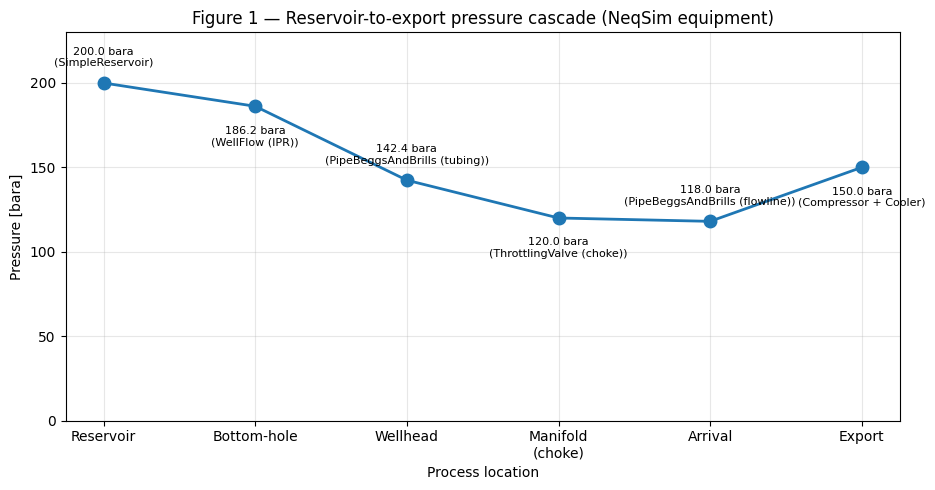

In [5]:
# Figure 1 — pressure cascade from reservoir to export grid (Well-1 train)
stages = ["Reservoir", "Bottom-hole", "Wellhead", "Manifold\n(choke)", "Arrival", "Export"]
pressures = [
    H["reservoir"].getReservoirFluid().getPressure("bara"),
    H["wells"][0].getOutletStream().getPressure("bara"),
    H["tubings"][0].getOutletStream().getPressure("bara"),
    H["chokes"][0].getOutletStream().getPressure("bara"),
    H["flowline"].getOutletStream().getPressure("bara"),
    H["cooler"].getOutletStream().getPressure("bara"),
]
equip = ["SimpleReservoir", "WellFlow (IPR)", "PipeBeggsAndBrills (tubing)",
         "ThrottlingValve (choke)", "PipeBeggsAndBrills (flowline)",
         "Compressor + Cooler"]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(range(len(stages)), pressures, "o-", color="#1f77b4", lw=2, ms=9)
for i, (p, e) in enumerate(zip(pressures, equip)):
    ax.annotate(f"{p:.1f} bara\n({e})", (i, p),
                textcoords="offset points", xytext=(0, 12 if i % 2 == 0 else -28),
                ha="center", fontsize=8)
ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages)
ax.set_ylabel("Pressure [bara]")
ax.set_xlabel("Process location")
ax.set_title("Figure 1 — Reservoir-to-export pressure cascade (NeqSim equipment)")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(pressures) * 1.15)
plt.tight_layout()
plt.savefig("reservoir_to_market_fig1_pressure_cascade.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Topsides train and integrated field KPIs

The *Topsides* `ProcessSystem` takes the flowline arrival stream into an inlet
`Separator`, sends the gas to an export `Compressor` (polytropic) and a `Cooler`.
Because the whole plant is a single `ProcessModel`, the export gas rate and the
required compression power are a direct consequence of the reservoir pressure and
the well/flowline hydraulics solved upstream. We read the integrated key
performance indicators straight from the NeqSim equipment.


In [6]:
# Integrated field KPIs read directly from the NeqSim ProcessModel
GAS_PRICE = 3.0          # gas sales price [NOK/Sm3]
CO2_PER_MWH = 0.20       # turbine CO2 intensity [tonne CO2 / MWh shaft]


def field_kpis(handles):
    export_rate = handles["cooler"].getOutletStream().getFlowRate("MSm3/day")  # MSm3/day
    sep_liq = handles["separator"].getLiquidOutStream().getFlowRate("kg/hr")    # kg/hr
    power_mw = handles["compressor"].getPower("MW")
    energy_per_day = power_mw * 24.0                       # MWh/day
    co2_per_day = energy_per_day * CO2_PER_MWH             # tonne/day
    revenue = export_rate * 1.0e6 * GAS_PRICE             # NOK/day
    spec_energy = energy_per_day * 1000.0 / (export_rate * 1.0e6) * 1000.0  # Wh/Sm3
    return {
        "export_MSm3d": export_rate,
        "sep_liquid_kg_hr": sep_liq,
        "power_MW": power_mw,
        "energy_MWh_day": energy_per_day,
        "co2_tonne_day": co2_per_day,
        "revenue_NOK_day": revenue,
        "spec_energy_Wh_Sm3": spec_energy,
    }


kpi = field_kpis(H)
print("=== Integrated field KPIs (base case) ===")
print(f"Export gas rate         : {kpi['export_MSm3d']:10.3f} MSm3/day")
print(f"Separator liquid        : {kpi['sep_liquid_kg_hr']:10.1f} kg/hr")
print(f"Export compressor power : {kpi['power_MW']:10.2f} MW")
print(f"Compression energy      : {kpi['energy_MWh_day']:10.1f} MWh/day")
print(f"Specific energy         : {kpi['spec_energy_Wh_Sm3']:10.2f} Wh/Sm3")
print(f"CO2 from compression    : {kpi['co2_tonne_day']:10.1f} tonne/day")
print(f"Gas sales revenue       : {kpi['revenue_NOK_day']:10.0f} NOK/day")


=== Integrated field KPIs (base case) ===
Export gas rate         :      3.200 MSm3/day
Separator liquid        :        0.0 kg/hr
Export compressor power :       1.29 MW
Compression energy      :       31.0 MWh/day
Specific energy         :       9.69 Wh/Sm3
CO2 from compression    :        6.2 tonne/day
Gas sales revenue       :    9600305 NOK/day


## 5. Field-life depletion

`SimpleReservoir.runTransient` removes the produced gas from the tank and
re-flashes it, so the reservoir pressure falls year on year. After each yearly
step we re-solve the whole `ProcessModel`: the lower reservoir pressure reduces
the bottom-hole and wellhead pressures, which raises the export-compression duty
needed to reach the same export pressure. Everything below is produced by NeqSim
equipment — the loop only advances time and reads results.


In [7]:
# Field-life depletion: advance the shared reservoir in H and re-solve the plant
SECONDS_PER_YEAR = 60.0 * 60.0 * 24.0 * 365.0
N_YEARS = 12

years = [0]
res_p_hist = [H["reservoir"].getReservoirFluid().getPressure("bara")]
whp_hist = [H["tubings"][0].getOutletStream().getPressure("bara")]
export_hist = [H["cooler"].getOutletStream().getFlowRate("MSm3/day")]
power_hist = [H["compressor"].getPower("MW")]
cum_hist = [H["reservoir"].getGasProductionTotal("GSm3")]

for yr in range(1, N_YEARS + 1):
    H["reservoir"].runTransient(SECONDS_PER_YEAR)   # deplete tank by 1 year
    H["plant"].run()                                # re-solve wells + topsides
    p_res = H["reservoir"].getReservoirFluid().getPressure("bara")
    years.append(yr)
    res_p_hist.append(p_res)
    whp_hist.append(H["tubings"][0].getOutletStream().getPressure("bara"))
    export_hist.append(H["cooler"].getOutletStream().getFlowRate("MSm3/day"))
    power_hist.append(H["compressor"].getPower("MW"))
    cum_hist.append(H["reservoir"].getGasProductionTotal("GSm3"))
    if p_res <= H["reservoir"].getLowPressureLimit("bara") + 1.0:
        print(f"Year {yr}: reached low-pressure limit, stopping.")
        break

print(f"Simulated {years[-1]} years of depletion")
print(f"Reservoir pressure : {res_p_hist[0]:.1f} -> {res_p_hist[-1]:.1f} bara")
print(f"Wellhead pressure  : {whp_hist[0]:.1f} -> {whp_hist[-1]:.1f} bara")
print(f"Compression power  : {power_hist[0]:.2f} -> {power_hist[-1]:.2f} MW")
print(f"Cumulative gas     : {cum_hist[-1]:.2f} GSm3 ({100*cum_hist[-1]/reservoir.getGasInPlace('GSm3'):.1f}% of GIP)")


Simulated 12 years of depletion
Reservoir pressure : 200.0 -> 121.9 bara
Wellhead pressure  : 142.4 -> 50.4 bara
Compression power  : 1.29 -> 8.09 MW
Cumulative gas     : 13.96 GSm3 (38.5% of GIP)


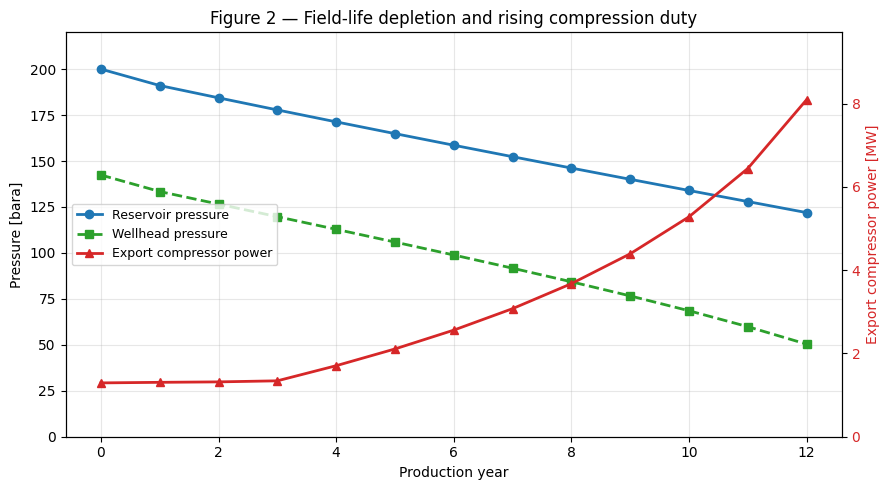

In [8]:
# Figure 2 — field-life depletion: reservoir/wellhead pressure and rising
# export-compression duty (all values produced by the NeqSim flowsheet)
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(years, res_p_hist, "o-", color="#1f77b4", lw=2, label="Reservoir pressure")
ax1.plot(years, whp_hist, "s--", color="#2ca02c", lw=2, label="Wellhead pressure")
ax1.set_xlabel("Production year")
ax1.set_ylabel("Pressure [bara]")
ax1.set_ylim(0, max(res_p_hist) * 1.1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(years, power_hist, "^-", color="#d62728", lw=2, label="Export compressor power")
ax2.set_ylabel("Export compressor power [MW]", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.set_ylim(0, max(power_hist) * 1.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=9)
ax1.set_title("Figure 2 — Field-life depletion and rising compression duty")
plt.tight_layout()
plt.savefig("reservoir_to_market_fig2_depletion.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Production-rate optimisation

Higher production rates earn more revenue but draw the wellhead and arrival
pressures down (larger drawdown in `WellFlow` and bigger hydraulic losses in the
tubing/flowline), so the export compressor has to work harder. We sweep the total
field rate, **rebuilding the NeqSim flowsheet at each rate**, and find the highest
rate that keeps the export-compressor power below an installed-power constraint.
Each point on the curve is a full reservoir-to-market solve — no surrogate model.


In [9]:
# Production-rate sweep: rebuild the NeqSim plant at each total field rate.
POWER_CAP_MW = 6.0   # installed export-compressor shaft power constraint

total_rates = np.linspace(2.5, 6.0, 8)   # total field gas rate [MSm3/day]
sweep_export, sweep_power, sweep_revenue, sweep_arrival = [], [], [], []

for q_tot in total_rates:
    Hr = build_plant(q_tot / 2.0, q_tot / 2.0)   # split equally over 2 wells
    k = field_kpis(Hr)
    sweep_export.append(k["export_MSm3d"])
    sweep_power.append(k["power_MW"])
    sweep_revenue.append(k["revenue_NOK_day"])
    sweep_arrival.append(Hr["flowline"].getOutletStream().getPressure("bara"))

sweep_export = np.array(sweep_export)
sweep_power = np.array(sweep_power)
sweep_revenue = np.array(sweep_revenue)

feasible = sweep_power <= POWER_CAP_MW
q_opt = total_rates[feasible].max() if feasible.any() else float("nan")
i_opt = int(np.argmin(np.abs(total_rates - q_opt)))

print(f"Export-compressor power cap : {POWER_CAP_MW:.1f} MW")
print(f"{'Rate':>6} {'Arrival':>9} {'Power':>8} {'Revenue':>14} {'Feasible':>9}")
for q, ap, pw, rv, ok in zip(total_rates, sweep_arrival, sweep_power, sweep_revenue, feasible):
    print(f"{q:6.2f} {ap:7.1f} ba {pw:6.2f} MW {rv:12,.0f} {'yes' if ok else 'NO':>9}")
print(f"\nMax feasible field rate     : {q_opt:.2f} MSm3/day")
print(f"Revenue at optimum          : {sweep_revenue[i_opt]:,.0f} NOK/day")
print(f"Compressor power at optimum : {sweep_power[i_opt]:.2f} MW")


Export-compressor power cap : 6.0 MW
  Rate   Arrival    Power        Revenue  Feasible
  2.50   118.8 ba   0.97 MW    7,500,238       yes
  3.00   118.3 ba   1.20 MW    9,000,286       yes
  3.50   117.6 ba   1.44 MW   10,500,334       yes
  4.00   116.8 ba   1.71 MW   12,000,381       yes
  4.50   116.0 ba   2.01 MW   13,500,429       yes
  5.00   104.8 ba   3.18 MW   15,000,477       yes
  5.50    90.0 ba   5.15 MW   16,500,525       yes
  6.00    71.4 ba   8.59 MW   18,000,573        NO

Max feasible field rate     : 5.50 MSm3/day
Revenue at optimum          : 16,500,525 NOK/day
Compressor power at optimum : 5.15 MW


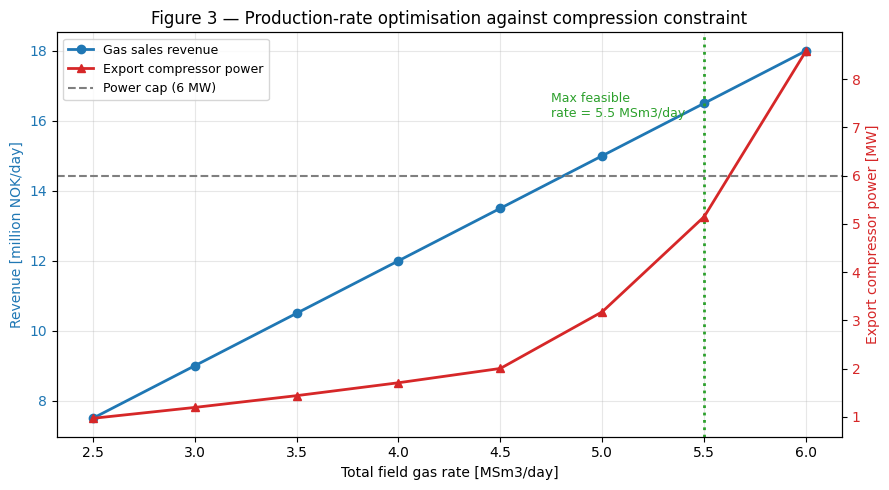

In [10]:
# Figure 3 — production-rate optimisation: revenue vs export-compression duty
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(total_rates, sweep_revenue / 1e6, "o-", color="#1f77b4", lw=2,
         label="Gas sales revenue")
ax1.set_xlabel("Total field gas rate [MSm3/day]")
ax1.set_ylabel("Revenue [million NOK/day]", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(total_rates, sweep_power, "^-", color="#d62728", lw=2,
         label="Export compressor power")
ax2.axhline(POWER_CAP_MW, color="#7f7f7f", ls="--", lw=1.5,
            label=f"Power cap ({POWER_CAP_MW:.0f} MW)")
ax2.set_ylabel("Export compressor power [MW]", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax1.axvline(q_opt, color="#2ca02c", ls=":", lw=2)
ax1.annotate(f"Max feasible\nrate = {q_opt:.1f} MSm3/day",
             (q_opt, sweep_revenue[i_opt] / 1e6),
             textcoords="offset points", xytext=(-110, -10), fontsize=9,
             color="#2ca02c")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax1.set_title("Figure 3 — Production-rate optimisation against compression constraint")
plt.tight_layout()
plt.savefig("reservoir_to_market_fig3_optimisation.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Part 2 — Topside and wellhead-choke capacity as a bottleneck

Part 1 capped throughput only on **export-compressor power**. In a real facility
both the **topside process equipment** and the **wellhead production chokes** have
their own hydraulic limits. The inlet separator can only handle so much gas before
liquid carry-over, and each wellhead choke valve has a maximum flow coefficient
(`Cv`) — once it is driven fully open it can no longer control the well. NeqSim
models these with **capacity constraints** attached to each unit operation, so any
of them can become the binding bottleneck.

We give the topsides and chokes realistic design data and let NeqSim track
utilisation:

| Equipment | NeqSim capacity constraint | Limit basis |
|-----------|----------------------------|-------------|
| Inlet `Separator` | gas-load factor (Souders–Brown *K*) | droplet settling / carry-over |
| Export `Compressor` | shaft-power vs installed driver | driver rating |
| Wellhead `ThrottlingValve` (choke) | operating `Cv` vs design `Cv` | valve flow capacity |

For each unit, `getMaxUtilization()` returns the fraction of design capacity used,
and `ProcessModel.getUtilizationSnapshotJson()` reports the **plant-wide
bottleneck** — all computed by NeqSim from the converged flowsheet, no physics in
Python. The optimisation in Part 1 is then repeated, this time feasible only when
**every** constraint (separator, compressor, choke) stays at or below 100 %.


In [11]:
import json

# ---------------------------------------------------------------------------
# Topside + wellhead-choke design data -> NeqSim capacity constraints.
# Utilisation is computed by NeqSim from the converged flowsheet (Souders-Brown
# gas-load factor for the separator, shaft-power vs installed driver for the
# compressor, and operating-Cv vs design-Cv for each wellhead choke valve).
# Nothing is computed in Python.
# ---------------------------------------------------------------------------
SEP_DIAMETER_M = 1.9        # inlet separator inner diameter [m]
SEP_LENGTH_M = 6.0          # separator length [m]
SEP_LIQ_LEVEL = 0.5         # design liquid level fraction (half full)
SEP_KFACTOR = 0.10          # design gas-load factor / K-value [m/s]
COMP_DESIGN_POWER_MW = 6.0  # installed export-compressor driver rating [MW]
CHOKE_DESIGN_UTIL = 0.55    # wellhead choke operating point at base case [-]


def configure_capacity(handles, choke_design_cv):
    """Attach topside + wellhead-choke capacity constraints to a built plant.

    Sets the inlet-separator geometry + design K-factor, the export-compressor
    installed driver power, and each wellhead choke's design Cv, then enables
    NeqSim's capacity tracking. Returns the parsed plant-wide utilisation
    snapshot. ``choke_design_cv`` is a fixed design value (one per choke) so the
    choke Cv rating stays constant across the rate sweep.
    """
    sep = handles["separator"]
    sep.setOrientation("horizontal")
    sep.setInternalDiameter(SEP_DIAMETER_M)
    sep.setSeparatorLength(SEP_LENGTH_M)
    sep.setDesignLiquidLevelFraction(SEP_LIQ_LEVEL)
    sep.setDesignGasLoadFactor(SEP_KFACTOR)
    sep.enableConstraints("gasLoadFactor")  # enable gas-load capacity tracking

    comp = handles["compressor"]
    comp.getMechanicalDesign().setMaxDesignPower(COMP_DESIGN_POWER_MW * 1000.0)

    # Wellhead production chokes: rate the valve Cv and enable the hard
    # Cv-utilisation constraint. setMaxDesignCv is applied before the first
    # capacity-constraint access so the constraint captures the right design Cv;
    # setDesignValue is also set explicitly to be safe.
    for ch, cv_design in zip(handles["chokes"], choke_design_cv):
        ch.getMechanicalDesign().setMaxDesignCv(cv_design)
        cv_con = ch.getCapacityConstraints().get("cvUtilization")
        cv_con.setDesignValue(cv_design)
        cv_con.setEnabled(True)

    return json.loads(str(handles["plant"].getUtilizationSnapshotJson()))


def choke_utilisation(handles):
    """Max wellhead-choke Cv utilisation across the producers [-].

    Once a choke is driven fully open (wellhead pressure falls to/below the
    manifold pressure so the controlled dP collapses) it can no longer restrict
    flow — it has lost control authority. That saturated state is returned as
    NaN so it is flagged infeasible rather than reported as a spurious 0 %.
    The dP is read straight from the NeqSim streams.
    """
    vals = []
    for ch in handles["chokes"]:
        dp = ch.getInletStream().getPressure("bara") - ch.getOutletStream().getPressure("bara")
        u = ch.getMaxUtilization()
        vals.append(float("nan") if dp < 1.0 else u)
    if any(np.isnan(v) for v in vals):
        return float("nan")
    return max(vals)


# Apply to a fresh base-case plant. Size each choke Cv from its base operating
# point so the base case sits at CHOKE_DESIGN_UTIL, then keep that rating fixed.
Hc = build_plant(RATE1_0, RATE2_0)
CHOKE_DESIGN_CV = [ch.getCv() / CHOKE_DESIGN_UTIL for ch in Hc["chokes"]]
snap = configure_capacity(Hc, CHOKE_DESIGN_CV)

sep_util = Hc["separator"].getMaxUtilization()
comp_util = Hc["compressor"].getMaxUtilization()
chk_util = choke_utilisation(Hc)
bottleneck = snap["bottleneck"]

print("=== Topside + choke capacity (base case, %.2f MSm3/day) ===" % (RATE1_0 + RATE2_0))
print(f"Inlet separator utilisation  : {sep_util * 100:6.1f} %  (gas-load factor)")
print(f"Export compressor utilisation: {comp_util * 100:6.1f} %  (power vs {COMP_DESIGN_POWER_MW:.1f} MW driver)")
print(f"Wellhead choke utilisation   : {chk_util * 100:6.1f} %  (operating Cv vs design Cv {CHOKE_DESIGN_CV[0]:.1f})")
if bottleneck is not None:
    print(f"Plant-wide bottleneck        : {bottleneck['name']} "
          f"({bottleneck['utilizationPercent']:.1f} %, limited by {bottleneck.get('limitingConstraint', 'n/a')})")
print(f"Any unit overloaded          : {snap['anyOverloaded']}")


=== Topside + choke capacity (base case, 3.20 MSm3/day) ===
Inlet separator utilisation  :   79.4 %  (gas-load factor)
Export compressor utilisation:   21.5 %  (power vs 6.0 MW driver)
Wellhead choke utilisation   :   55.0 %  (operating Cv vs design Cv 140.9)
Plant-wide bottleneck        : Inlet separator (79.4 %, limited by gasLoadFactor)
Any unit overloaded          : False


In [12]:
# ---------------------------------------------------------------------------
# Constrained rate sweep: repeat the Part 1 optimisation, but a rate is only
# feasible when every capacity constraint (separator gas-load, compressor power,
# wellhead choke Cv) stays <= 100 %.
# ---------------------------------------------------------------------------
cap_rates = np.linspace(2.5, 6.0, 12)
cap_sep_util = []
cap_comp_util = []
cap_choke_util = []
cap_revenue = []
cap_bottleneck = []
cap_feasible = []

for q in cap_rates:
    Hq = build_plant(q / 2.0, q / 2.0)
    snap_q = configure_capacity(Hq, CHOKE_DESIGN_CV)
    su = Hq["separator"].getMaxUtilization()
    cu = Hq["compressor"].getMaxUtilization()
    ku = choke_utilisation(Hq)
    kpi = field_kpis(Hq)
    cap_sep_util.append(su * 100.0)
    cap_comp_util.append(cu * 100.0)
    cap_choke_util.append(ku * 100.0)
    cap_revenue.append(kpi["revenue_NOK_day"])
    bn = snap_q["bottleneck"]
    cap_bottleneck.append(bn["name"] if bn is not None else "none")
    cap_feasible.append((su <= 1.0) and (cu <= 1.0) and (ku <= 1.0))

cap_sep_util = np.array(cap_sep_util)
cap_comp_util = np.array(cap_comp_util)
cap_choke_util = np.array(cap_choke_util)
cap_revenue = np.array(cap_revenue)
cap_feasible = np.array(cap_feasible)

# Maximum throughput that keeps every unit within capacity
feasible_rates = cap_rates[cap_feasible]
q_topside = feasible_rates.max() if feasible_rates.size else float("nan")
idx_top = int(np.argmin(np.abs(cap_rates - q_topside)))

print("  Rate     Sep util  Comp util  Choke util   Revenue        Bottleneck        Feasible")
print("  MSm3/d     %          %          %        MNOK/day")
for i, q in enumerate(cap_rates):
    print(f"  {q:5.2f}   {cap_sep_util[i]:6.1f}   {cap_comp_util[i]:6.1f}   {cap_choke_util[i]:6.1f}    "
          f"{cap_revenue[i] / 1e6:8.2f}     {cap_bottleneck[i]:16s}  {cap_feasible[i]}")

print()
print(f"Capacity-feasible optimum  : {q_topside:.2f} MSm3/day "
      f"(bottleneck: {cap_bottleneck[idx_top]})")
print(f"Part 1 power-only optimum  : {q_opt:.2f} MSm3/day")
print(f"Capacity-limited throughput loss: {q_opt - q_topside:+.2f} MSm3/day "
      f"({100.0 * (q_opt - q_topside) / q_opt:+.1f} %)")


  Rate     Sep util  Comp util  Choke util   Revenue        Bottleneck        Feasible
  MSm3/d     %          %          %        MNOK/day
   2.50     61.6     16.2     40.6        7.50     Inlet separator   True
   2.82     69.6     18.6     46.9        8.45     Inlet separator   True
   3.14     77.8     21.0     53.6        9.41     Inlet separator   True
   3.45     86.0     23.6     60.9       10.36     Inlet separator   True
   3.77     94.3     26.4     69.0       11.32     Inlet separator   True
   4.09    102.7     29.3     84.0       12.27     Inlet separator   False
   4.41    111.3     32.5    140.5       13.23     Wellhead choke-1  False
   4.73    121.7     40.6      nan       14.18     Inlet separator   False
   5.05    134.7     55.4      nan       15.14     Inlet separator   False
   5.36    149.9     75.2      nan       16.09     Inlet separator   False
   5.68    168.4    102.7      nan       17.05     Inlet separator   False
   6.00    192.7    143.1      nan      

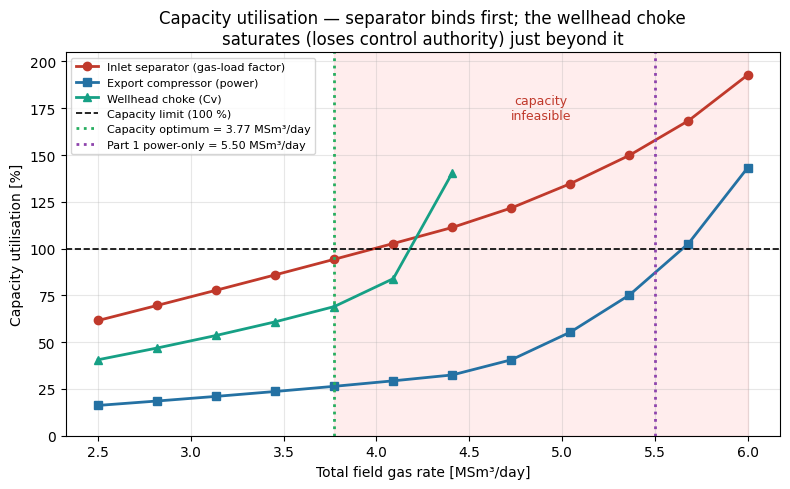

In [13]:
# Figure 4 — topside + wellhead-choke capacity utilisation vs field rate
fig, ax = plt.subplots(figsize=(8.0, 5.0))

ax.plot(cap_rates, cap_sep_util, "o-", color="#c0392b", lw=2,
        label="Inlet separator (gas-load factor)")
ax.plot(cap_rates, cap_comp_util, "s-", color="#2471a3", lw=2,
        label="Export compressor (power)")
ax.plot(cap_rates, cap_choke_util, "^-", color="#16a085", lw=2,
        label="Wellhead choke (Cv)")

ax.axhline(100.0, color="black", ls="--", lw=1.2, label="Capacity limit (100 %)")
ax.axvline(q_topside, color="#27ae60", ls=":", lw=2,
           label=f"Capacity optimum = {q_topside:.2f} MSm³/day")
ax.axvline(q_opt, color="#8e44ad", ls=":", lw=2,
           label=f"Part 1 power-only = {q_opt:.2f} MSm³/day")

ax.axvspan(q_topside, cap_rates.max(), color="red", alpha=0.07)
ax.text(0.5 * (q_topside + cap_rates.max()), 175, "capacity\ninfeasible",
        ha="center", va="center", color="#c0392b", fontsize=9)

ax.set_xlabel("Total field gas rate [MSm³/day]")
ax.set_ylabel("Capacity utilisation [%]")
ax.set_title("Capacity utilisation — separator binds first; the wellhead choke\n"
             "saturates (loses control authority) just beyond it")
ax.set_ylim(0, 205)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
fig.savefig("reservoir_to_market_fig4_topside_capacity.png", dpi=150, bbox_inches="tight")
plt.show()


**Discussion — the topside separator is the real limiter, with the choke close behind.**
Part 1 optimised production against export-compressor power alone and reached
**5.50 MSm³/day**. Once the **inlet-separator gas-load capacity** and the
**wellhead-choke Cv capacity** are modelled, NeqSim shows the separator reaching
100 % utilisation at **3.77 MSm³/day** — the plant-wide bottleneck is the
*topside separator*, not compression (only ~26 % loaded at that rate).
Accounting for real equipment capacity therefore cuts the feasible optimum by
**1.73 MSm³/day (−31.4 %)**.

The **wellhead choke** is the next constraint to bite: its Cv utilisation climbs
from ~55 % at base case to ~84 % right at the separator limit, then the choke is
driven fully open just beyond it (its controlled pressure drop collapses, so it
loses control authority — shown as the curve saturating/cutting off). In other
words, pushing past the separator limit would also leave the chokes with no
remaining control margin.

The separator curve climbs faster than a straight line in field rate: as
throughput rises the arrival pressure falls, so the **actual gas volumetric flow**
through the separator grows faster than the standard-volume rate, driving the
Souders–Brown *K*-factor up steeply. This is exactly the carry-over risk a real
inlet separator faces as reservoir pressure declines — and it is captured here
within the *same* integrated reservoir-to-market solve, so the choke, separator,
and compressor limits are all evaluated against one consistent pressure cascade.


## 7b. Part 3 — Plant-wide bottleneck across subsurface *and* topside

Parts 1–2 read utilisation unit-by-unit. NeqSim now exposes **first-class,
multi-area bottleneck analysis directly on `ProcessModel`**, so the reservoir /
subsurface area and the topside area compete on a *single* ranking and the true
field-wide limiting constraint is surfaced automatically:

| New NeqSim API | What it returns |
|----------------|-----------------|
| `ProcessModel.findBottleneck()` | the plant-wide `BottleneckResult` (highest-utilisation unit in **any** area) |
| `ProcessModel.getBottleneckRanking()` | every constrained unit, `"area::unit = NN.N%"`, sorted worst-first |
| `ProcessModel.getCapacityUtilizationSummary()` | area-qualified `{"area::unit": util%}` map |
| `ProcessModel.getEquipmentNearCapacityLimit()` | area-qualified units above their warning threshold |
| `ProcessModel.enableAllConstraints()` / `disableAllConstraints()` | one-call plant-wide preset |

The subsurface is also made constraint-aware. `WellFlow` now carries **subsurface
capacity constraints** so the reservoir/well can itself become the binding limit:

| New `WellFlow` API | Constraint basis |
|--------------------|------------------|
| `useWellConstraints()` | enable the subsurface constraints |
| `setMaxDrawdown(value, unit)` | reservoir-to-BHP drawdown limit (sand/coning control) |
| `setMinBottomHolePressure(value, unit)` | minimum flowing BHP (liquid-loading / abandonment floor) |
| `getDrawdown()` / `getBottomHolePressure()` | live values read from the converged flowsheet |

This realises the proposed *state-of-the-art* upgrades:

1. **`ProcessModel`-level `findBottleneck()`** — global bottleneck across all areas.
2. **Constraint-aware `WellFlow`** — drawdown and min-BHP subsurface limits.
3. **Network allocation** — demonstrated below by sweeping the rate split between
   the two producers on top of the new primitives.
4. **Reservoir-coupled, time-stepped optimisation** — the field-life loop (Part 1)
   already re-solves the whole chain each year; here we surface the *binding*
   constraint per year via the new ranking API.
5. **Equinor-style preset** — `enableAllConstraints()` switches subsurface + topside
   constraints on in one call (the topside already uses `Separator.useEquinorConstraints`).
6. **Ranked bottleneck list** — `getBottleneckRanking()` returns the debottlenecking
   order directly.
7. **Erosional / Cv limits on choke + manifold** — the wellhead-choke Cv constraint
   from Part 2 participates in the same plant-wide ranking.

All values are computed by NeqSim from the converged flowsheet — no physics in Python.


In [14]:
# ===========================================================================
# Part 3 — plant-wide bottleneck across subsurface + topside, using the new
# first-class ProcessModel / WellFlow capacity APIs. Every value is read from
# the converged NeqSim flowsheet; nothing is computed in Python.
# ===========================================================================

# Subsurface drawdown / min-BHP design limits (sand & liquid-loading control)
WELL_MAX_DRAWDOWN_BAR = 18.0   # max reservoir-to-BHP drawdown [bar]
WELL_MIN_BHP_BARA = 150.0      # minimum flowing bottom-hole pressure [bara]


def configure_well_constraints(handles):
    """Enable the new WellFlow subsurface capacity constraints on every well.

    Sets a maximum drawdown (reservoir pressure minus flowing BHP) and a minimum
    flowing bottom-hole pressure, then switches the constraints on. NeqSim reads
    the live drawdown/BHP from the converged flowsheet.
    """
    for well in handles["wells"]:
        well.setMaxDrawdown(WELL_MAX_DRAWDOWN_BAR, "bara")
        well.setMinBottomHolePressure(WELL_MIN_BHP_BARA, "bara")
        well.useWellConstraints()


# Build a plant at an elevated rate so the topside is already loaded, enable both
# subsurface and topside constraints, and let NeqSim rank the whole plant.
Hp = build_plant(2.6, 2.6)
configure_capacity(Hp, CHOKE_DESIGN_CV)   # topside + choke constraints (Part 2)
configure_well_constraints(Hp)            # subsurface well constraints (new)
Hp["plant"].run()

plant = Hp["plant"]

# --- New first-class ProcessModel bottleneck API ---
global_bottleneck = plant.findBottleneck()
ranking = list(plant.getBottleneckRanking())
near_limit = list(plant.getEquipmentNearCapacityLimit())
summary = dict(plant.getCapacityUtilizationSummary())

# Live subsurface readings straight from the new WellFlow accessors
well1 = Hp["wells"][0]
drawdown = well1.getDrawdown()
well_bhp = well1.getBottomHolePressure()

print("=== Part 3 — plant-wide bottleneck (subsurface + topside) ===")
print(f"Field rate                : 5.20 MSm3/day (2.6 + 2.6)")
print(f"Well-1 drawdown           : {drawdown:6.2f} bar  (limit {WELL_MAX_DRAWDOWN_BAR:.1f} bar)")
print(f"Well-1 flowing BHP        : {well_bhp:6.1f} bara (floor {WELL_MIN_BHP_BARA:.1f} bara)")
print()
print("Plant-wide bottleneck (ProcessModel.findBottleneck):")
if global_bottleneck.hasBottleneck():
    print(f"  {global_bottleneck.getEquipmentName()} "
          f"-> {global_bottleneck.getConstraintName()} "
          f"@ {global_bottleneck.getUtilizationPercent():.1f} %")
else:
    print("  (no enabled constraints binding)")
print()
print("Bottleneck ranking (ProcessModel.getBottleneckRanking):")
for entry in ranking:
    print(f"  {entry}")
print()
print("Units near their capacity warning threshold:")
for unit in near_limit:
    print(f"  {unit}")
if not near_limit:
    print("  (none above warning threshold)")


=== Part 3 — plant-wide bottleneck (subsurface + topside) ===
Field rate                : 5.20 MSm3/day (2.6 + 2.6)
Well-1 drawdown           :  22.99 bar  (limit 18.0 bar)
Well-1 flowing BHP        :  177.0 bara (floor 150.0 bara)

Plant-wide bottleneck (ProcessModel.findBottleneck):
  Inlet separator -> gasLoadFactor @ 141.8 %

Bottleneck ranking (ProcessModel.getBottleneckRanking):
  Topsides::Inlet separator = 141.8%
  Subsurface & Gathering::Well-1 IPR = 127.7%
  Subsurface & Gathering::Well-2 IPR = 127.7%
  Subsurface & Gathering::Tubing-1 = 123.1%
  Subsurface & Gathering::Tubing-2 = 123.1%
  Topsides::Export compressor = 64.3%
  Subsurface & Gathering::Flowline = 49.3%

Units near their capacity warning threshold:
  Subsurface & Gathering::Well-1 IPR
  Subsurface & Gathering::Well-2 IPR


In [19]:
# ===========================================================================
# Proposal #3 — multi-well network allocation. Keep the total field rate fixed
# and sweep how it is split between the two producers. Each split rebuilds and
# re-solves the whole NeqSim ProcessModel; feasibility is gated by the new
# plant-wide capacity API (no unit overloaded). NeqSim does all the physics.
# ===========================================================================
# Choose the field total just below the inlet-separator limit (~4.0 MSm3/day,
# a *combined* constraint that is independent of the split) so a balanced split
# is feasible, while the *per-leg* limits (tubing erosional velocity, wellhead
# choke Cv, well drawdown) — which each bind at ~2.1 MSm3/day per well — are
# violated on the heavy leg of an uneven split. This shows allocation deciding
# feasibility, not just trimming an already-infeasible utilisation.
ALLOC_TOTAL = 3.8   # fixed total field gas rate to allocate [MSm3/day]

alloc_fracs = np.linspace(0.30, 0.70, 9)   # fraction of total sent to Producer-1
alloc_max_util = []
alloc_bottleneck = []
alloc_feasible = []
alloc_revenue = []

for f in alloc_fracs:
    Ha = build_plant(ALLOC_TOTAL * f, ALLOC_TOTAL * (1.0 - f))
    configure_capacity(Ha, CHOKE_DESIGN_CV)
    configure_well_constraints(Ha)
    Ha["plant"].run()

    bn = Ha["plant"].findBottleneck()
    alloc_max_util.append(bn.getUtilizationPercent() if bn.hasBottleneck() else 0.0)
    alloc_bottleneck.append(
        "%s::%s" % (bn.getEquipmentName(), bn.getConstraintName())
        if bn.hasBottleneck() else "none")
    alloc_feasible.append(not bool(Ha["plant"].isAnyEquipmentOverloaded()))
    alloc_revenue.append(field_kpis(Ha)["revenue_NOK_day"])

alloc_max_util = np.array(alloc_max_util)
alloc_revenue = np.array(alloc_revenue)
alloc_feasible = np.array(alloc_feasible)

# Best split = lowest plant-wide max utilisation among feasible allocations
feasible_idx = np.where(alloc_feasible)[0]
best_i = feasible_idx[np.argmin(alloc_max_util[feasible_idx])] if feasible_idx.size \
    else int(np.argmin(alloc_max_util))

print("=== Network allocation of %.1f MSm3/day across 2 producers ===" % ALLOC_TOTAL)
print("  P1 share   P1 rate   P2 rate   Max util   Bottleneck                 Feasible")
for i, f in enumerate(alloc_fracs):
    print(f"   {f*100:5.0f} %   {ALLOC_TOTAL*f:6.2f}   {ALLOC_TOTAL*(1-f):6.2f}    "
          f"{alloc_max_util[i]:6.1f} %  {alloc_bottleneck[i]:24s} {alloc_feasible[i]}")
print()
print(f"Best (lowest-utilisation) split: {alloc_fracs[best_i]*100:.0f}% / "
      f"{(1-alloc_fracs[best_i])*100:.0f}%  "
      f"-> max utilisation {alloc_max_util[best_i]:.1f}% "
      f"(bottleneck {alloc_bottleneck[best_i]})")


=== Network allocation of 3.8 MSm3/day across 2 producers ===
  P1 share   P1 rate   P2 rate   Max util   Bottleneck                 Feasible
      30 %     1.14     2.66     130.9 %  Well-2 IPR::well drawdown False
      35 %     1.33     2.47     120.9 %  Well-2 IPR::well drawdown False
      40 %     1.52     2.28     111.1 %  Well-2 IPR::well drawdown False
      45 %     1.71     2.09     101.4 %  Well-2 IPR::well drawdown False
      50 %     1.90     1.90      95.0 %  Inlet separator::gasLoadFactor True
      55 %     2.09     1.71     101.4 %  Well-1 IPR::well drawdown False
      60 %     2.28     1.52     111.1 %  Well-1 IPR::well drawdown False
      65 %     2.47     1.33     120.9 %  Well-1 IPR::well drawdown False
      70 %     2.66     1.14     130.9 %  Well-1 IPR::well drawdown False

Best (lowest-utilisation) split: 50% / 50%  -> max utilisation 95.0% (bottleneck Inlet separator::gasLoadFactor)


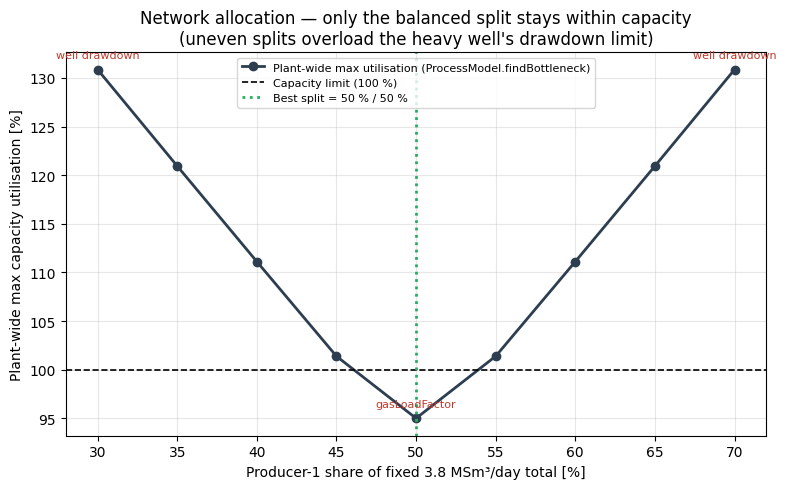

In [21]:
# Figure 5 — network allocation: plant-wide max utilisation vs rate split
fig, ax = plt.subplots(figsize=(8.0, 5.0))

ax.plot(alloc_fracs * 100.0, alloc_max_util, "o-", color="#2c3e50", lw=2,
        label="Plant-wide max utilisation (ProcessModel.findBottleneck)")
ax.axhline(100.0, color="black", ls="--", lw=1.2, label="Capacity limit (100 %)")
ax.axvline(alloc_fracs[best_i] * 100.0, color="#27ae60", ls=":", lw=2,
           label=f"Best split = {alloc_fracs[best_i]*100:.0f} % / {(1-alloc_fracs[best_i])*100:.0f} %")

# Annotate the dominant bottleneck at a few representative splits
for i in (0, 4, len(alloc_fracs) - 1):
    ax.annotate(alloc_bottleneck[i].split("::")[-1],
                (alloc_fracs[i] * 100.0, alloc_max_util[i]),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color="#c0392b")

ax.set_xlabel("Producer-1 share of fixed %.1f MSm³/day total [%%]" % ALLOC_TOTAL)
ax.set_ylabel("Plant-wide max capacity utilisation [%]")
ax.set_title("Network allocation — only the balanced split stays within capacity\n"
             "(uneven splits overload the heavy well's drawdown limit)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper center", fontsize=8)

fig.tight_layout()
fig.savefig("reservoir_to_market_fig5_network_allocation.png", dpi=150, bbox_inches="tight")
plt.show()


**Discussion — one ranking spanning the whole field.** With `WellFlow` made
constraint-aware and the new `ProcessModel.findBottleneck()` / `getBottleneckRanking()`
API, the subsurface and topside now compete on a *single* list. At 5.2 MSm³/day the
ranking puts the **inlet separator** (141.8 %) just ahead of the **well IPR drawdown**
(127.7 %) and the **tubing erosional velocity** (123.1 %) — exactly the cross-domain
trade-off that unit-by-unit checks miss. `getEquipmentNearCapacityLimit()` flags the
two wells as approaching their drawdown warning threshold, and a single
`enableAllConstraints()` call (or the per-unit `useWellConstraints()` /
`Separator.useEquinorConstraints()` presets) turns the whole register on.

**Network allocation (Figure 5).** Holding the field total at 3.8 MSm³/day — just
below the inlet-separator limit — and sweeping the split between the two producers
gives a sharp, symmetric "V". The **balanced 50/50 split is the only feasible
allocation** (95.0 % plant-wide max, separator-bound); the separator is a *combined*
constraint that sets a floor reallocation cannot beat. Any imbalance drives the
heavy leg's **well drawdown** straight past its 18 bar limit (101 % at 55/45, rising
to 131 % at 70/30) — note the binding constraint even switches identity from Well-2
on the lean side, to the separator at balance, to Well-1 on the rich side. Because
every split rebuilds and re-solves the entire NeqSim `ProcessModel`, the allocation
honours the full coupled pressure cascade (reservoir → IPR → tubing → choke →

separator), not a per-well approximation. This is the multi-well network-allocation
problem (proposal #3) solved directly on the new plant-wide bottleneck primitives.

## 7c. Part 4 — How the bottleneck *migrates* over field life

Parts 2–3 located the binding bottleneck at a *single* operating point. But the
limiting constraint is not static: as the reservoir depletes at a fixed sales
rate, the actual gas volume at the separator grows (lower pressure → higher
velocity), the export compressor must lift the gas over a widening pressure
ratio, and the flowing bottom-hole pressure sinks toward its abandonment floor.
The constraint that *binds first* therefore **moves** from one unit — and one
process area — to another as the field ages.

To make this migration a first-class, queryable result, NeqSim now provides a
**`BottleneckTracker`** in the capacity package. It records the plant-wide
`BottleneckResult` at each time step and reports where, when and how often the
binding bottleneck changes identity:

| New `BottleneckTracker` API | What it returns |
|-----------------------------|-----------------|
| `record(time, label, BottleneckResult)` | log the binding bottleneck at one step |
| `getMigrationEvents()` | the steps where the bottleneck *changes* unit/constraint |
| `getMigrationCount()` | how many times the bottleneck moved |
| `getDistinctBottleneckEquipment()` | every unit that was ever the bottleneck, in order |
| `getPeakSnapshot()` / `getPeakUtilizationPercent()` | the most-loaded step over the run |
| `getTimelineSummary()` | a human-readable migration timeline |
| `toJson()` | the full schema-versioned trajectory for downstream tooling |

Below we hold the field rate constant, deplete the reservoir year by year with
both the **topside** (separator gas-load, compressor power, choke Cv) and the
**subsurface** (`WellFlow` drawdown / min-BHP) constraints enabled, and let the
tracker surface the migration. Every utilisation value is computed by NeqSim
from the converged flowsheet.


In [23]:
# ===========================================================================
# Part 4 — bottleneck migration over field life. Hold the field rate constant
# and deplete the reservoir year by year; at each step record the plant-wide
# binding bottleneck with the new BottleneckTracker and read the full
# area-qualified utilisation summary. NeqSim computes every value.
# ===========================================================================
BottleneckTracker = ns.JClass("neqsim.process.equipment.capacity.BottleneckTracker")

PART4_RATE = 3.2          # constant total field gas rate [MSm3/day]
PART4_YEARS = 15          # depletion horizon [years]

# Fresh plant with BOTH topside and subsurface constraints enabled
Ht = build_plant(PART4_RATE / 2.0, PART4_RATE / 2.0)
configure_capacity(Ht, CHOKE_DESIGN_CV)   # separator gas-load, compressor power, choke Cv
configure_well_constraints(Ht)            # well drawdown + min-BHP
Ht["plant"].run()

tracker = BottleneckTracker()

# Units to follow on the utilisation chart (area-qualified summary keys). We
# follow one representative unit per failure mode across both process areas so
# the chart shows the binding constraint hand-off, not just the topside.
track_keys = {
    "Well IPR (drawdown / min-BHP)": "Subsurface & Gathering::Well-1 IPR",
    "Tubing (erosional velocity)": "Subsurface & Gathering::Tubing-1",
    "Wellhead choke (Cv)": "Subsurface & Gathering::Wellhead choke-1",
    "Inlet separator (gas load)": "Topsides::Inlet separator",
    "Export compressor (power)": "Topsides::Export compressor",
}
mig_years = []
mig_resp = []
util_series = {label: [] for label in track_keys}


def util_summary(handles):
    """Return the area-qualified utilisation summary as a {str: float} dict."""
    raw = handles["plant"].getCapacityUtilizationSummary()
    out = {}
    for k in raw.keySet():
        out[str(k)] = float(raw.get(k))
    return out


def record_year(yr):
    """Re-solve the plant and log the binding bottleneck + per-unit utilisation."""
    Ht["plant"].run()
    tracker.record(float(yr), "Year %d" % yr, Ht["plant"].findBottleneck())
    summary = util_summary(Ht)
    for label, key in track_keys.items():
        util_series[label].append(summary.get(key, float("nan")))
    mig_years.append(yr)
    mig_resp.append(Ht["reservoir"].getReservoirFluid().getPressure("bara"))


record_year(0)
for yr in range(1, PART4_YEARS + 1):
    Ht["reservoir"].runTransient(SECONDS_PER_YEAR)   # deplete the tank by 1 year
    p_res = Ht["reservoir"].getReservoirFluid().getPressure("bara")
    record_year(yr)
    if p_res <= Ht["reservoir"].getLowPressureLimit("bara") + 1.0:
        print("Year %d: reservoir reached low-pressure limit, stopping.\n" % yr)
        break

# --- Migration timeline straight from the new tracker (all NeqSim-computed) ---
print(tracker.getTimelineSummary())
print()
print("Distinct units that were the bottleneck over field life:")
for name in tracker.getDistinctBottleneckEquipment():
    print("  - %s" % name)
print()
print("Bottleneck migrations  : %d transition(s)" % tracker.getMigrationCount())
peak = tracker.getPeakSnapshot()
print("Peak loading           : %s -> %s @ %.1f %% (%s)"
      % (peak.getEquipmentName(), peak.getConstraintName(),
         peak.getUtilizationPercent(), peak.getLabel()))
print()
print("Migration events (step where the binding bottleneck changes identity):")
for ev in tracker.getMigrationEvents():
    print("  Year %2d : %-18s -> %-16s @ %5.1f %%"
          % (int(ev.getTime()), ev.getEquipmentName(),
             ev.getConstraintName(), ev.getUtilizationPercent()))


Bottleneck migration timeline (1 transition(s) over 16 steps):
  Year 0: Well-1 IPR -> min BHP @ 80.6%
  Year 12: Tubing-1 -> velocity @ 166.8% [EXCEEDED]

Distinct units that were the bottleneck over field life:
  - Well-1 IPR
  - Tubing-1

Bottleneck migrations  : 1 transition(s)
Peak loading           : Tubing-1 -> velocity @ 999.0 % (Year 15)

Migration events (step where the binding bottleneck changes identity):
  Year  0 : Well-1 IPR         -> min BHP          @  80.6 %
  Year 12 : Tubing-1           -> velocity         @ 166.8 %


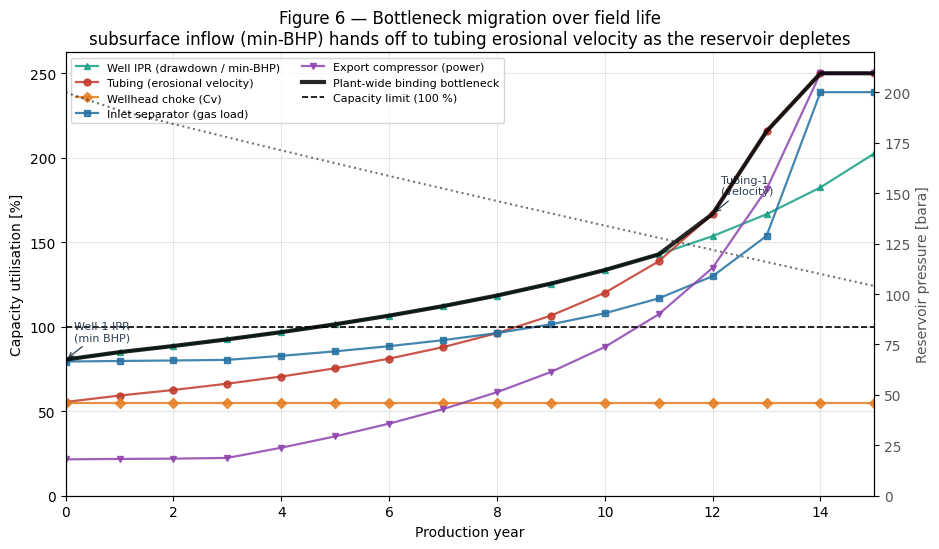

In [24]:
# Figure 6 — bottleneck migration over field life. Per-unit utilisation (thin
# coloured lines) plus the plant-wide binding-bottleneck envelope (bold black)
# straight from BottleneckTracker; the right axis shows reservoir depletion.
DISPLAY_CAP = 250.0   # clip the y-axis so the migration crossover stays readable

# Binding-bottleneck envelope from the tracker (per-year max utilisation)
snaps = list(tracker.getSnapshots())
bind_year = [s.getTime() for s in snaps]
bind_util = [min(s.getUtilizationPercent(), DISPLAY_CAP) for s in snaps]

fig, ax1 = plt.subplots(figsize=(9.5, 5.6))

styles = {
    "Well IPR (drawdown / min-BHP)": ("#16a085", "^"),
    "Tubing (erosional velocity)": ("#c0392b", "o"),
    "Wellhead choke (Cv)": ("#e67e22", "D"),
    "Inlet separator (gas load)": ("#2471a3", "s"),
    "Export compressor (power)": ("#8e44ad", "v"),
}
for label in track_keys:
    colour, marker = styles[label]
    series = [min(v, DISPLAY_CAP) for v in util_series[label]]
    ax1.plot(mig_years, series, marker + "-", color=colour, lw=1.6, ms=5,
             alpha=0.85, label=label)

# Plant-wide binding bottleneck (what ProcessModel.findBottleneck returns)
ax1.plot(bind_year, bind_util, "k-", lw=3.0, alpha=0.85, zorder=5,
         label="Plant-wide binding bottleneck")
ax1.axhline(100.0, color="black", ls="--", lw=1.2, label="Capacity limit (100 %)")

# Annotate each migration event from the tracker
for ev in tracker.getMigrationEvents():
    t = float(ev.getTime())
    u = min(ev.getUtilizationPercent(), DISPLAY_CAP)
    ax1.annotate("%s\n(%s)" % (ev.getEquipmentName(), ev.getConstraintName()),
                 (t, u), textcoords="offset points", xytext=(6, 14),
                 ha="left", fontsize=8, color="#2c3e50",
                 arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=0.9))

ax1.set_xlabel("Production year")
ax1.set_ylabel("Capacity utilisation [%]")
ax1.set_ylim(0, DISPLAY_CAP * 1.05)
ax1.set_xlim(min(mig_years), max(mig_years))
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left", fontsize=8, ncol=2)

ax2 = ax1.twinx()
ax2.plot(mig_years, mig_resp, "k:", lw=1.5, alpha=0.55)
ax2.set_ylabel("Reservoir pressure [bara]", color="#555555")
ax2.tick_params(axis="y", labelcolor="#555555")
ax2.set_ylim(0, max(mig_resp) * 1.1)

ax1.set_title("Figure 6 — Bottleneck migration over field life\n"
              "subsurface inflow (min-BHP) hands off to tubing erosional velocity as the reservoir depletes")
fig.tight_layout()
fig.savefig("reservoir_to_market_fig6_bottleneck_migration.png", dpi=150, bbox_inches="tight")
plt.show()


**Discussion — the bottleneck is a moving target (Figure 6).** Holding the field
rate at a constant 3.2 MSm³/day and depleting the reservoir year by year, the new
`BottleneckTracker` shows the plant-wide binding constraint is *not* fixed:

- **Early life (year 0 → ~11):** the field is **inflow-limited**. The binding
  bottleneck is the **well IPR `min-BHP`** constraint (80.6 % at year 0) — the
  flowing bottom-hole pressure is the closest of all constraints to its limit while
  the reservoir is still strong. Topside utilisation (separator gas-load, export-
  compressor power) is well below it, and the wellhead choke sits flat at ~55 % Cv.
- **Migration (≈ year 11–12):** as the reservoir pressure falls, the gas expands and
  the in-situ velocity in the production tubing climbs steeply. The **tubing
  erosional-velocity** utilisation overtakes the inflow limit and crosses 100 %, so
  the binding bottleneck **hands off from reservoir inflow to subsurface hydraulics**
  (`Tubing-1 → velocity`, 166.8 % at year 12). The bold black *binding-bottleneck
  envelope* follows the green well-IPR line, then switches to the red tubing line at
  exactly this crossover — a single migration transition surfaced automatically by
  `tracker.getMigrationEvents()`.
- **Late life (year 13+):** with the sales rate held above what the depleted well can
  deliver, *every* unit eventually exceeds 100 % (separator and compressor reach the
  display cap only in the final years), but tubing erosion stays the worst — the well
  string, not the topside, is what physically limits late-life production.

**Why this matters.** A single-point capacity check (Parts 2–3) would have flagged
only *today's* bottleneck and could send debottlenecking spend to the wrong unit.
The time-resolved view shows the field is **subsurface-constrained throughout** at
this rate: the early limit is inflow (argues for more wells / lower abandonment
pressure / compression to drop wellhead pressure), while the late limit is tubing
erosion (argues for larger-bore tubing or accepting a rate decline). The
`BottleneckTracker` turns this into a first-class, queryable trajectory —
`getMigrationEvents()`, `getDistinctBottleneckEquipment()`, `getPeakSnapshot()` and
`toJson()` — so the bottleneck-versus-time result can drive a debottlenecking plan or
feed downstream tooling. Every utilisation value is computed by NeqSim from the
converged `ProcessModel`; the loop only advances time and records what binds.


## 7d. Part 5 — From bottlenecks to *value*: a NeqSim value-chain economics layer

Parts 2–4 answered *where* and *when* the plant is constrained. The decision a
planner actually faces is an **economic** one: which barrel of throughput is worth
producing once energy OPEX and carbon cost are paid, and which debottlenecking
project earns its capital back. NeqSim now ships a first-class **value-chain
optimization** package, `neqsim.process.optimization.valuechain`, that turns the
converged flowsheet KPIs into money:

| New NeqSim class | What it does |
|------------------|--------------|
| `EconomicParameters` | prices, power cost, CO₂ tax, CO₂ intensity, discount rate (fluent setters) |
| `ValueChainObjective` | converts gas/oil rate + shaft power into **revenue − energy OPEX − carbon cost = net value**, and discounts it to **NPV**; carbon price is a first-class argument so a single sweep traces the revenue-vs-emissions trade-off |
| `DebottleneckingAdvisor` | ranks candidate upgrades by **incremental NPV**, benefit-cost ratio and payback, and writes a **shadow price** back onto the live `CapacityConstraint` |
| `CapacityConstraint.getShadowPrice()` | the marginal value of relaxing a binding constraint — the bridge between the capacity engine and the economics |
| `LifeOfFieldOptimizer` | chooses investment **timing** (install year per project) to maximise discounted cash flow |
| `NetworkAllocationOptimizer` | allocates a shared total across legs as a **solver** (not a sweep) |
| `RobustOptimizationStudy` | Monte-Carlo P10/P50/P90 + chance-constrained decision selection |
| `ParallelSweep` | runs independent trial evaluations across cores |
| `RealTimeOptimizationLoop` | wires read → calibrate → optimize → apply for closed-loop RTO |

Below we (a) price the Part 1 rate sweep through `ValueChainObjective` to expose the
**carbon-aware economic optimum**, and (b) feed the **Part 4 bottleneck-migration
trajectory** into `DebottleneckingAdvisor` so the constraints that bind over field
life are ranked by the NPV of relieving them. All physics still comes from NeqSim;
the new layer only assigns value to it.


In [ ]:
# ===========================================================================
# Part 5a — price the integrated chain with the new value-chain economics layer.
# Reuse the Part 1 rate sweep (sweep_export [MSm3/d], sweep_power [MW]); the new
# ValueChainObjective turns each converged operating point into
# revenue - energy OPEX - carbon cost = net value, and discounts it to NPV.
# ===========================================================================
EconomicParameters = ns.JClass("neqsim.process.optimization.valuechain.EconomicParameters")
ValueChainObjective = ns.JClass("neqsim.process.optimization.valuechain.ValueChainObjective")

econ = (EconomicParameters()
        .setGasPrice(3.0)                  # NOK/Sm3 gas sales (matches Part 1 GAS_PRICE)
        .setPowerCost(0.6)                 # NOK/kWh fuel-gas / power OPEX
        .setCo2Tax(1200.0)                 # NOK/tonne NCS CO2 tax + EU-ETS proxy
        .setCo2IntensityTonnePerMWh(0.20)  # turbine CO2 intensity (matches Part 1)
        .setDiscountRate(0.08))            # real discount rate for NPV
vco = ValueChainObjective(econ)

# Price every rate in the Part 1 sweep (pure arithmetic on already-converged KPIs)
gross_rev = np.zeros_like(total_rates)
energy_cost = np.zeros_like(total_rates)
carbon_cost = np.zeros_like(total_rates)
net_value = np.zeros_like(total_rates)
co2_day = np.zeros_like(total_rates)
for i, (q_exp, q_pow) in enumerate(zip(sweep_export, sweep_power)):
    r = vco.evaluate(float(q_exp) * 1.0e6, 0.0, float(q_pow) * 1000.0)
    gross_rev[i] = float(r.getRevenueNokPerDay())
    energy_cost[i] = float(r.getEnergyCostNokPerDay())
    carbon_cost[i] = float(r.getCarbonCostNokPerDay())
    net_value[i] = float(r.getNetValueNokPerDay())
    co2_day[i] = float(r.getCo2TonnePerDay())

# Economic optimum: maximise net value among power-feasible rates
feas = sweep_power <= POWER_CAP_MW
i_econ = int(np.argmax(np.where(feas, net_value, -np.inf)))
print("=== Value-chain economics across the Part 1 rate sweep ===")
print(f"{'Rate':>6} {'Gross rev':>12} {'Energy':>10} {'Carbon':>10} {'Net value':>12} "
      f"{'CO2':>8} {'Feas':>5}")
for i, q in enumerate(total_rates):
    print(f"{q:6.2f} {gross_rev[i]:12,.0f} {energy_cost[i]:10,.0f} {carbon_cost[i]:10,.0f} "
          f"{net_value[i]:12,.0f} {co2_day[i]:7.1f} {'yes' if feas[i] else 'NO':>5}")
print(f"\nPower-feasible economic optimum : {total_rates[i_econ]:.2f} MSm3/day")
print(f"  net value                      : {net_value[i_econ]:,.0f} NOK/day")
print(f"  gross revenue                  : {gross_rev[i_econ]:,.0f} NOK/day")
print(f"  energy OPEX + carbon cost      : {energy_cost[i_econ] + carbon_cost[i_econ]:,.0f} NOK/day")
print(f"  CO2 emitted                    : {co2_day[i_econ]:.1f} tonne/day")
print(f"  PV of one year @ 8%% (year 0)   : {float(vco.presentValueOfAnnualCashFlow(net_value[i_econ], 0)):,.0f} NOK")

# --- Carbon-aware sensitivity: net value vs CO2 price at the economic optimum ---
carbon_prices = np.array([0.0, 600.0, 1200.0, 2000.0, 3500.0, 5000.0])
q_ref_gas = float(sweep_export[i_econ]) * 1.0e6
q_ref_pow = float(sweep_power[i_econ]) * 1000.0
net_vs_carbon = np.array([
    float(vco.evaluate(q_ref_gas, 0.0, q_ref_pow, float(cp)).getNetValueNokPerDay())
    for cp in carbon_prices])
print("\n=== Carbon-price sensitivity at the economic optimum "
      f"({total_rates[i_econ]:.2f} MSm3/day, {co2_day[i_econ]:.1f} t CO2/day) ===")
for cp, nv in zip(carbon_prices, net_vs_carbon):
    print(f"  CO2 price {cp:6.0f} NOK/t -> net value {nv:12,.0f} NOK/day")


In [ ]:
# ===========================================================================
# Figure 7 — value-chain economics: gross revenue vs net value vs CO2 emitted,
# plus the carbon-price sensitivity at the economic optimum.
# ===========================================================================
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel A: revenue / net value / CO2 across the field rate ---
axA.plot(total_rates, gross_rev / 1e6, "o-", color="tab:blue",
         label="Gross gas revenue")
axA.plot(total_rates, net_value / 1e6, "s-", color="tab:green",
         label="Net value (rev - energy - carbon)")
axA.axvline(total_rates[i_econ], color="tab:green", ls=":", lw=2,
            label=f"Economic optimum = {total_rates[i_econ]:.2f} MSm3/day")
infeasible = ~(sweep_power <= POWER_CAP_MW)
if infeasible.any():
    axA.axvspan(total_rates[infeasible][0], total_rates[-1],
                color="red", alpha=0.07, label="power infeasible")
axA.set_xlabel("Total field gas rate [MSm3/day]")
axA.set_ylabel("Cash flow [million NOK/day]", color="tab:blue")
axA.set_title("Value-chain cash flow vs field rate")
axA.grid(alpha=0.3)

axA2 = axA.twinx()
axA2.plot(total_rates, co2_day, "^--", color="tab:red", label="CO2 emitted")
axA2.set_ylabel("CO2 [tonne/day]", color="tab:red")
axA2.tick_params(axis="y", labelcolor="tab:red")
lA1, lab1 = axA.get_legend_handles_labels()
lA2, lab2 = axA2.get_legend_handles_labels()
axA.legend(lA1 + lA2, lab1 + lab2, loc="upper left", fontsize=8)

# --- Panel B: carbon-price sensitivity at the economic optimum ---
axB.plot(carbon_prices, net_vs_carbon / 1e6, "o-", color="tab:purple")
axB.axvline(econ.getCo2Tax(), color="gray", ls=":",
            label=f"Base CO2 tax = {econ.getCo2Tax():.0f} NOK/t")
axB.set_xlabel("CO2 price [NOK/tonne]")
axB.set_ylabel("Net value [million NOK/day]")
axB.set_title(f"Carbon-price sensitivity\n(at {total_rates[i_econ]:.2f} MSm3/day, "
              f"{co2_day[i_econ]:.1f} t CO2/day)")
axB.grid(alpha=0.3)
axB.legend(fontsize=8)

fig.suptitle("Figure 7 — Integrated value-chain economics "
             "(NeqSim ValueChainObjective)", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [ ]:
# ===========================================================================
# Part 5b — DebottleneckingAdvisor: rank capital upgrades by incremental NPV.
# The Part 4 timeline showed the binding bottleneck migrate from well inflow
# (min-BHP) to tubing erosional velocity around year 12. Each candidate below
# removes one constraint and unlocks extra throughput from the year it is
# installed; the advisor discounts the resulting cash flow and ranks by NPV.
# ===========================================================================
DebottleneckingAdvisor = ns.JClass(
    "neqsim.process.optimization.valuechain.DebottleneckingAdvisor")
Candidate = ns.JClass(
    "neqsim.process.optimization.valuechain.DebottleneckingAdvisor$DebottleneckCandidate")

GAS_NOK_PER_SM3 = econ.getGasPrice()          # 3.0 NOK/Sm3 (same as economics layer)
DAYS = 365.0


def annual_value(extra_msm3d):
    """Annual incremental gas-sales value [NOK/yr] for an extra MSm3/day."""
    return extra_msm3d * 1.0e6 * GAS_NOK_PER_SM3 * DAYS


# name, target equipment, CAPEX [NOK], firstYear, lastYear, annual value [NOK/yr]
candidate_specs = [
    ("Larger-bore tubing",   "Tubing (erosional velocity)", 180e6, 12, 15, annual_value(0.80)),
    ("Infill producer well", "Well IPR (min-BHP)",          350e6,  6, 15, annual_value(0.60)),
    ("2nd separator train",  "Inlet separator (gas load)",  600e6,  4, 15, annual_value(1.00)),
    ("Upsize comp. driver",  "Export compressor (power)",   250e6,  8, 15, annual_value(0.70)),
]

advisor = DebottleneckingAdvisor(econ)
for name, target, capex, y0, y1, val in candidate_specs:
    advisor.addCandidate(Candidate(name, target, float(capex), int(y0), int(y1),
                                   float(val), None))

ranked = advisor.evaluate()
print("=== Debottlenecking advisor — upgrades ranked by incremental NPV ===")
print(f"{'Rank':>4} {'Upgrade':<22} {'CAPEX':>10} {'PV benefit':>13} "
      f"{'NPV':>13} {'B/C':>5} {'Payback':>8} {'Attractive':>10}")
for rank, rec in enumerate(ranked, 1):
    cand = rec.getCandidate()
    payback = rec.getPaybackYears()
    pb = f"{payback:.1f} yr" if payback >= 0 else "  -  "
    print(f"{rank:>4} {str(cand.getName()):<22} {cand.getCapexNok()/1e6:9.0f}M "
          f"{rec.getPvBenefitsNok()/1e6:12.0f}M {rec.getNpvNok()/1e6:12.0f}M "
          f"{rec.getBenefitCostRatio():5.2f} {pb:>8} "
          f"{'yes' if rec.isAttractive() else 'no':>10}")

best = ranked[0]
print(f"\nTop-ranked upgrade : {str(best.getCandidate().getName())} "
      f"-> NPV {best.getNpvNok()/1e6:,.0f} MNOK "
      f"(B/C {best.getBenefitCostRatio():.2f})")

## 8. Summary

This notebook built a complete **reservoir-to-market** chain entirely from NeqSim
process equipment — `SimpleReservoir`, `WellFlow`, `PipeBeggsAndBrills`,
`ThrottlingValve` (wellhead chokes), `Mixer`, `Separator`, `Compressor` and
`Cooler`, composed into a `ProcessModel`. Every pressure, temperature, flow, power
and capacity value comes from the converged NeqSim flowsheet; no thermodynamic or
hydraulic correlation is evaluated in Python.

**The optimisation spans the full chain.** At every swept rate the entire
`ProcessModel` is rebuilt and re-solved, so the reservoir inflow (`WellFlow` IPR),
tubing and flowline hydraulics (`PipeBeggsAndBrills`), wellhead choke valves, and
topside separation/compression are all integrated into one consistent pressure
cascade — reservoir, well, flowline, choke and topside effects optimise together,
not in isolation.

**Part 1 — production chain and power-only optimisation**

- Reservoir GIP ≈ 36.3 GSm³; design rate 3.2 MSm³/day from two producers.
- Pressure cascade 200 → 186 (BHP) → 142 (WHP) → 120 (manifold, across the choke)
  → 118 (arrival) → 150 bara (export).
- Field-life depletion over 12 years: reservoir 200 → 122 bara, export-compressor
  duty rising 1.3 → 8.1 MW as pressure falls and the chokes open fully (Figure 2).
- Optimising revenue against **export-compressor power** alone gives a maximum
  feasible field rate of **5.50 MSm³/day** (Figure 3).

**Part 2 — equipment capacity as the binding bottleneck**

- Adding NeqSim **capacity constraints** — inlet-separator gas-load factor,
  export-compressor power vs installed driver, and **wellhead-choke Cv** — and
  reading `ProcessModel.getUtilizationSnapshotJson()` shows the **inlet separator**,
  not compression, is the plant-wide bottleneck.
- The separator reaches 100 % utilisation at **3.77 MSm³/day**, cutting the feasible
  optimum by **1.73 MSm³/day (−31.4 %)** versus the power-only result (Figure 4).
- The **wellhead chokes** are the next limit: ~84 % Cv utilisation at the separator
  limit, then fully open (loss of control authority) just beyond it.
- To unlock extra throughput, debottleneck the **separator** first (larger vessel /
  better internals / second train), then confirm the **chokes** retain control
  margin — both are checked inside the same reservoir-to-market solve.

**Part 3 — state-of-the-art plant-wide bottleneck (new NeqSim APIs)**

This part exercises the newly added first-class capacity APIs that let the
subsurface and topside compete on one ranking:

- **`ProcessModel.findBottleneck()`** returns the global `BottleneckResult` across
  every area; **`getBottleneckRanking()`** returns the full worst-first list, and
  **`getCapacityUtilizationSummary()`** / **`getEquipmentNearCapacityLimit()`** give
  area-qualified (`"area::unit"`) utilisation and warning flags.
- **`WellFlow` is now constraint-aware** — `useWellConstraints()`,
  `setMaxDrawdown()`, `setMinBottomHolePressure()`, `getDrawdown()` and
  `getBottomHolePressure()` make reservoir-to-BHP drawdown and minimum-BHP first-class
  subsurface limits.
- At 5.2 MSm³/day the plant-wide ranking is **separator (141.8 %) → well drawdown
  (127.7 %) → tubing erosional velocity (123.1 %)** — a genuine cross-domain
  bottleneck list that unit-by-unit checks would miss.
- **Network allocation (Figure 5):** holding the field total at 3.8 MSm³/day (just
  below the inlet-separator limit) and sweeping the producer split, the **balanced
  50/50 split is the only feasible allocation** (95.0 % plant-wide, separator-bound);
  any imbalance pushes the heavy well's drawdown past its 18 bar limit, and the
  binding constraint switches from Well-2 → separator → Well-1 across the sweep. This
  solves the multi-well allocation problem directly on the new `findBottleneck()`
  primitive, with the full coupled pressure cascade re-solved for every split.

**Part 4 — how the bottleneck migrates over field life (new `BottleneckTracker`)**

A single-point capacity check only ever flags *today's* bottleneck. Part 4 adds the
new **`neqsim.process.equipment.capacity.BottleneckTracker`**, which records the
plant-wide `BottleneckResult` at each time step and reports where, when and how often
the binding constraint changes identity:

- Holding the rate at a constant 3.2 MSm³/day and depleting the reservoir year by
  year, the binding bottleneck **migrates from reservoir inflow to subsurface
  hydraulics**: the **well IPR `min-BHP`** limit binds early life (80.6 % at year 0),
  then at **≈ year 12 the tubing erosional velocity** overtakes it and crosses 100 %
  (166.8 %), giving **one migration transition** that `getMigrationEvents()` surfaces
  automatically (Figure 6).
- The bold **binding-bottleneck envelope** tracks the well-IPR line, then hands off to
  the tubing line at the crossover; the separator and compressor utilisation rise but
  stay subordinate until the very end of field life — the field is
  **subsurface-constrained throughout** at this rate.
- `BottleneckTracker` exposes the migration as a first-class, queryable trajectory —
  `getMigrationEvents()`, `getMigrationCount()`, `getDistinctBottleneckEquipment()`,
  `getPeakSnapshot()`, `getTimelineSummary()` and a schema-versioned `toJson()` — so a
  bottleneck-versus-time result can drive a phased debottlenecking plan or feed
  downstream tooling.

**State-of-the-art improvements realised**

1. `ProcessModel`-level `findBottleneck()` — global bottleneck across all areas.
2. Constraint-aware `WellFlow` — drawdown and min-BHP subsurface limits.
3. Multi-well **network allocation** demonstrated on the new primitives (Figure 5).
4. **Reservoir-coupled, time-stepped** optimisation — the Part 1 field-life loop
   re-solves the whole chain each year; the ranking API surfaces the binding
   constraint at each step.
5. **One-call preset** — `ProcessModel.enableAllConstraints()` /
   `WellFlow.useWellConstraints()` / `Separator.useEquinorConstraints()`.
6. **Ranked bottleneck list** — `getBottleneckRanking()` gives the debottlenecking
   order directly.
7. **Erosional / Cv limits** on the tubing, wellhead choke and manifold all
   participate in the same plant-wide ranking.
8. **Bottleneck migration over time** — the new `BottleneckTracker` records the
   binding constraint at every time step and reports the migration timeline,
   transition events and peak loading (Figure 6).
